# AI Ghostwriter — Adattamento e Tuning per la Divina Commedia

In questo notebook è stato adattato il prototipo di generazione testuale char-level, originariamente addestrato su Shakespeare, al testo della **Divina Commedia** di Dante Alighieri.

L'obiettivo è triplice:
1. **Data Swapping** — sostituire il corpus shakespeariano con il testo dantesco, confrontando i due vocabolari.
2. **Hyperparameter Tuning** — esplorare l'effetto della **temperatura** di campionamento sul bilanciamento tra grammatica e creatività poetica.
3. **Prompt Engineering** — adattare il prompt di generazione al contesto medievale italiano.

### Pipeline

1. **Setup** — import, seed globale, costanti
2. **Analisi del Prototipo (Shakespeare)** — download, vocabolario di riferimento
3. **Dataset Dante** — download con `requests`, encoding UTF-8, vocabolario
4. **Creazione del Dataset** — `tf.data`, sequenze, batching
5. **Architettura del Modello** — Embedding → GRU → GRU → Dense
6. **Training** — curva di loss, EarlyStopping
7. **Generazione e Temperatura** — esperimento temperature con prompt danteschi
8. **Conclusioni** — temperatura ottimale e miglior testo generato

---

## 1. Setup e Configurazione

In [2]:
import random
import numpy as np
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import matplotlib as mpl
import requests
import urllib3

# --- Riproducibilità ---
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# --- Costanti globali ---
SEQ_LENGTH    = 128
BATCH_SIZE    = 64
BUFFER_SIZE   = 10000
EMBEDDING_DIM = 256
RNN_UNITS     = 1024
DROPOUT_RATE  = 0.3
EPOCHS        = 200
TEMPERATURES  = [0.1, 0.5, 1.0, 1.5, 2.0]
PROMPT_DANTE  = ["Nel mezzo ", "Fatti non foste ", "Amor, c'ha nullo amato "]
NUM_GENERATE  = 512
N_TEST = 3

# --- Stile grafico ---
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams.update({
    'figure.dpi'        : 120,
    'figure.facecolor'  : 'white',
    'font.family'       : 'sans-serif',
    'font.size'         : 11,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'lines.linewidth'   : 2,
    'legend.frameon'    : True,
    'legend.framealpha' : 0.9,
    'legend.fontsize'   : 10,
})

COLOR = {
    'blue'  : '#2196F3',
    'red'   : '#E91E63',
    'green' : '#4CAF50',
    'orange': '#FF9800',
    'purple': '#9C27B0',
}

print('=' * 70)
print('SETUP COMPLETATO'.center(70))
print('=' * 70)
print(f'  TensorFlow : {tf.__version__}')
print(f'  Keras      : {keras.__version__}')
print(f'  NumPy      : {np.__version__}')
print(f'  GPU        : {tf.config.list_physical_devices("GPU")}')
print(f'  Seed       : {RANDOM_STATE}')
print('=' * 70)


                           SETUP COMPLETATO                           
  TensorFlow : 2.21.0
  Keras      : 3.14.0
  NumPy      : 2.4.3
  GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
  Seed       : 42


---

## 2. Analisi del Prototipo (Shakespeare)

Prima di procedere con il cambio di dataset, verrà scaricato e analizzato rapidamente il corpus shakespeariano originale. Il numero di caratteri unici rappresenta il punto di confronto rispetto al vocabolario della Divina Commedia, che includerà caratteri accentati tipici dell'italiano medievale (`à`, `è`, `ì`, `ò`, `ù`).

In [3]:
def analizza_corpus(testo: str, nome: str) -> dict:
    """
    Costruisce il vocabolario di un corpus testuale e stampa le statistiche principali.

    Parametri:
        testo: stringa contenente l'intero corpus
        nome: nome descrittivo del corpus (usato nell'output)

    Ritorna:
        dizionario con chiavi 'vocab', 'char2idx', 'idx2char', 'text_as_int'
    """
    vocab    = sorted(set(testo))
    char2idx = {u: i for i, u in enumerate(vocab)}
    idx2char = np.array(vocab)
    text_as_int = np.array([char2idx[c] for c in testo])

    print(f'\n  [{nome}]')
    print(f'  Lunghezza corpus   : {len(testo):>10,} caratteri')
    print(f'  Caratteri unici    : {len(vocab):>10}')
    print(f'  Esempio (30 char)  : {repr(testo[100:130])}')
    print(f'  Vocabolario        : {vocab}')

    return {'vocab': vocab, 'char2idx': char2idx, 'idx2char': idx2char, 'text_as_int': text_as_int}


# Download corpus Shakespeare
print('=' * 70)
print('ANALISI PROTOTIPO SHAKESPEARE'.center(70))
print('=' * 70)

path_shakespeare = tf.keras.utils.get_file(
    'shakespeare.txt',
    'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt'
)
testo_shakespeare = open(path_shakespeare, 'rb').read().decode(encoding='utf-8')
info_shakespeare  = analizza_corpus(testo_shakespeare, 'Shakespeare')

print('\n' + '=' * 70)

                    ANALISI PROTOTIPO SHAKESPEARE                     

  [Shakespeare]
  Lunghezza corpus   :  1,115,394 caratteri
  Caratteri unici    :         65
  Esempio (30 char)  : ' are all resolved rather to di'
  Vocabolario        : ['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']



### Osservazioni — Vocabolario Shakespeare

Il corpus shakespeariano contiene **65 caratteri unici**: lettere maiuscole e minuscole dell'alfabeto inglese, punteggiatura, spazi e caratteri speciali. L'assenza di caratteri accentati riflette la struttura della lingua inglese, che non utilizza diacritici.

Questo valore sarà il riferimento: ci si aspetta che il vocabolario dantesco sia **leggermente più ampio**, includendo i caratteri accentati italiani (`à`, `è`, `é`, `ì`, `ò`, `ù`) assenti nell'inglese.

---

## 3. Download del Dataset: Dante Alighieri

Si procedo ora a sostituire il corpus shakespeariano con la **Divina Commedia**. Il download avviene tramite la libreria `requests` con `verify=False` per gestire i certificati SSL del server universitario. L'encoding è impostato esplicitamente a `utf-8` per preservare i caratteri accentati italiani.

In [4]:
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)


def scarica_testo_dante() -> str:
    """
    Scarica il testo della Divina Commedia ignorando gli errori di certificato SSL.
    In caso di fallimento, tenta un URL di riserva su GitHub.

    Parametri:
        Nessuno.

    Ritorna:
        testo: stringa UTF-8 contenente l'intero poema, oppure None se entrambi i download falliscono
    """
    url_primario = 'https://dmf.unicatt.it/~della/pythoncourse18/commedia.txt'
    url_riserva  = 'https://raw.githubusercontent.com/wpm/t-sne-text-vis/master/data/divina_commedia.txt'

    print(f'  Scaricamento da: {url_primario} ...')
    try:
        response = requests.get(url_primario, verify=False, timeout=15)
        response.raise_for_status()
        response.encoding = 'utf-8'
        testo = response.text
        print(f'  Download completato — {len(testo):,} caratteri')
        return testo
    except Exception as e:
        print(f'  Errore URL primario: {e}')
        print(f'  Tentativo URL di riserva: {url_riserva} ...')
        try:
            r2 = requests.get(url_riserva, verify=False, timeout=15)
            r2.encoding = 'utf-8'
            print(f'  Download di riserva completato — {len(r2.text):,} caratteri')
            return r2.text
        except Exception as e2:
            print(f'  Errore URL di riserva: {e2}')
            return None


print('=' * 70)
print('DOWNLOAD DIVINA COMMEDIA'.center(70))
print('=' * 70)

testo_dante_raw = scarica_testo_dante()
assert testo_dante_raw is not None, 'Download fallito: verificare la connessione'

# Rimozione intestazione del file (i primi 55 caratteri sono metadati)
testo_dante = testo_dante_raw[55:]

print(f'\n  Esempio (primi 200 caratteri del poema):')
print(f'  {repr(testo_dante[:200])}')
print('=' * 70)

                       DOWNLOAD DIVINA COMMEDIA                       
  Scaricamento da: https://dmf.unicatt.it/~della/pythoncourse18/commedia.txt ...
  Download completato — 551,846 caratteri

  Esempio (primi 200 caratteri del poema):
  'Inferno: Canto I\r\n\r\n  Nel mezzo del cammin di nostra vita\r\nmi ritrovai per una selva oscura\r\nché la diritta via era smarrita.\r\n  Ahi quanto a dir qual era è cosa dura\r\nesta selva selvaggia e aspra e f'


### Preprocessing e Confronto Vocabolari

In [5]:
# Costruzione vocabolario Dante
info_dante = analizza_corpus(testo_dante, 'Dante — Divina Commedia')

# Estrazione variabili globali necessarie per training e generazione
vocab    = info_dante['vocab']
char2idx = info_dante['char2idx']
idx2char = info_dante['idx2char']

# Confronto vocabolari
print('\n' + '=' * 70)
print('CONFRONTO VOCABOLARI'.center(70))
print('=' * 70)

vocab_shakespeare = set(info_shakespeare['vocab'])
vocab_dante_set   = set(info_dante['vocab'])

solo_dante       = vocab_dante_set - vocab_shakespeare
solo_shakespeare = vocab_shakespeare - vocab_dante_set

print(f'  Shakespeare  : {len(vocab_shakespeare)} caratteri unici')
print(f'  Dante        : {len(vocab_dante_set)} caratteri unici')
print(f'  Solo in Dante        : {sorted(solo_dante)}')
print(f'  Solo in Shakespeare  : {sorted(solo_shakespeare)}')
print('=' * 70)


  [Dante — Divina Commedia]
  Lunghezza corpus   :    551,791 caratteri
  Caratteri unici    :         69
  Esempio (30 char)  : 'diritta via era smarrita.\r\n  A'
  Vocabolario        : ['\n', '\r', ' ', '!', '"', "'", '(', ')', ',', '-', '.', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'X', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'x', 'y', 'z', '~', 'à', 'è', 'é', 'ì', 'ï', 'ò', 'ó', 'ù']

                         CONFRONTO VOCABOLARI                         
  Shakespeare  : 65 caratteri unici
  Dante        : 69 caratteri unici
  Solo in Dante        : ['\r', '"', '(', ')', '~', 'à', 'è', 'é', 'ì', 'ï', 'ò', 'ó', 'ù']
  Solo in Shakespeare  : ['$', '&', '3', 'J', 'K', 'W', 'Y', 'k', 'w']


### Osservazioni — Confronto Vocabolari

Il vocabolario dantesco contiene un numero di caratteri unici **leggermente superiore** a quello shakespeariano, ma con una composizione diversa:

| Aspetto | Shakespeare | Dante |
|---|---|---|
| **Caratteri accentati** | Assenti | Presenti (`à`, `è`, `é`, `ì`, `ò`, `ù`) |
| **Lettere maiuscole** | Ampio set (drammi, personaggi) | Set ridotto (solo inizio verso/canto) |
| **Caratteri speciali** | `$`, `&`, etc. | Tilde `~` (segno editoriale) |

I caratteri accentati sono **fondamentali** per la corretta generazione dell'italiano: senza encoding UTF-8 esplicito, questi caratteri verrebbero corrotti, rendendo il testo generato illeggibile. L'impostazione `response.encoding = 'utf-8'` nella funzione di download garantisce la preservazione di tutta la ricchezza fonetica del volgare dantesco.

---

## 4. Creazione del Dataset di Addestramento

È stato utilizzato `tf.data` per costruire il dataset in modo efficiente. Ogni sequenza di input ha lunghezza `SEQ_LENGTH` e il target corrispondente è la stessa sequenza **shiftata di un carattere**: il modello impara a predire il carattere successivo dato il contesto precedente.

La scelta di `SEQ_LENGTH = 128` è motivata dalla struttura metrica della Commedia: le terzine di endecasillabi hanno circa 35–45 caratteri ciascuna, e un contesto di 128 caratteri copre almeno una terzina completa — sufficiente per apprendere lo schema metrico senza appesantire inutilmente la memoria della GRU.

In [7]:
def split_input_target(chunk: tf.Tensor):
    """
    Divide un chunk di testo in sequenza di input e target shiftato di un carattere.

    Parametri:
        chunk: tensore 1D di lunghezza seq_length + 1

    Ritorna:
        input_text : tensore di lunghezza seq_length (caratteri 0 … L-1)
        target_text: tensore di lunghezza seq_length (caratteri 1 … L)
    """
    return chunk[:-1], chunk[1:]


def crea_dataset_addestramento(
    text_as_int: np.ndarray,
    seq_length: int,
    batch_size: int,
    buffer_size: int
) -> tf.data.Dataset:
    """
    Costruisce il tf.data.Dataset per l'addestramento del modello char-level.

    Parametri:
        text_as_int : array di interi (indici carattere)
        seq_length  : lunghezza della finestra temporale di input
        batch_size  : dimensione del batch
        buffer_size : dimensione del buffer per lo shuffling

    Ritorna:
        dataset: tf.data.Dataset pronto per model.fit()
    """
    char_dataset = tf.data.Dataset.from_tensor_slices(text_as_int)
    # Sequenze di lunghezza seq_length + 1: un carattere in più per costruire il target
    sequences = char_dataset.batch(seq_length + 1, drop_remainder=True)
    dataset = sequences.map(split_input_target)
    dataset = (
        dataset
        .cache()
        .shuffle(buffer_size)
        .batch(batch_size, drop_remainder=True)
        .prefetch(tf.data.AUTOTUNE)
    )
    return dataset


text_as_int = info_dante['text_as_int']
dataset     = crea_dataset_addestramento(text_as_int, SEQ_LENGTH, BATCH_SIZE, BUFFER_SIZE)

print('=' * 70)
print('DATASET DI ADDESTRAMENTO'.center(70))
print('=' * 70)
print(f'  Caratteri totali  : {len(text_as_int):>10,}')
print(f'  Seq length        : {SEQ_LENGTH:>10,}')
print(f'  Batch size        : {BATCH_SIZE:>10,}')

for input_batch, target_batch in dataset.take(1):
    print(f'  Shape input batch :  {input_batch.shape}')
    print(f'  Shape target batch:  {target_batch.shape}')

print('=' * 70)

                       DATASET DI ADDESTRAMENTO                       
  Caratteri totali  :    551,791
  Seq length        :        128
  Batch size        :         64
  Shape input batch :  (64, 128)
  Shape target batch:  (64, 128)


### Osservazioni — Impatto di `seq_length` sulla Velocità di Training

Ridurre `seq_length` da 100 a 80 ha due effetti contrapposti:

| Effetto | Descrizione |
|---|---|
| **Velocità** | Ogni batch contiene più operazioni nella GRU (128 step invece di 100): ogni epoca è più lenta |
| **Numero batch** | Con sequenze più lunghe si generano meno sequenze dallo stesso corpus: il dataset è comunque ricco |
| **Contesto** | La rete vede più storia passata: ciò aiuta il modello a mantenere la coerenza su strutture metriche lunghe |

Per le terzine dantesche (ognuna ~3 × 11 sillabe ≈ 40 caratteri), `seq_length = 128` copre almeno una terzina: sufficiente per imparare le formule linguistiche ricorrenti del poema.

---

## 5. Architettura del Modello

Il modello segue l'architettura del prototipo shakespeariano con due aggiunte: layer **Dropout** dopo ogni GRU per regolarizzare il training su un corpus di medie dimensioni.

```
Input (seq_length,)             
    │                           
Embedding(vocab_size, 256)      
    │                           
GRU(1024, return_sequences=True)
    │                           
Dropout(0.3)                    
    │                           
GRU(1024, return_sequences=True)
    │                           
Dropout(0.3)                    
    │                           
Dense(vocab_size)               ← logits grezzi (senza softmax, usati con temperatura)
```

L'ultimo layer produce **logits** (non probabilità): questo permette di controllare la distribuzione dividendo per la temperatura **prima** del campionamento, senza modificare il modello né aggiungere una softmax fissa.


In [8]:
def build_model(
    vocab_size: int,
    embedding_dim: int,
    rnn_units: int,
    dropout_rate: float
) -> keras.Model:
    """
    Costruisce il modello di generazione testuale a livello di carattere.

    Architettura:
        Input -> Embedding -> GRU1 -> Dropout -> GRU2 -> Dropout -> Dense(vocab_size)
    Il Dropout e applicato dopo ogni GRU per ridurre l overfitting sul corpus.
    Il Dense finale produce logits grezzi (senza softmax) per consentire il
    tuning della temperatura durante la generazione.

    Parametri:
        vocab_size    : numero di caratteri unici nel vocabolario
        embedding_dim : dimensione dello spazio di embedding
        rnn_units     : numero di unita nascoste in ogni layer GRU
        dropout_rate  : tasso di dropout applicato dopo ogni GRU

    Ritorna:
        model: keras.Sequential costruito e pronto per il summary
    """
    model = keras.Sequential([
        keras.Input(shape=(None,), dtype='int32'),
        keras.layers.Embedding(vocab_size, embedding_dim),
        keras.layers.GRU(rnn_units, return_sequences=True, recurrent_initializer='glorot_uniform'),
        keras.layers.Dropout(dropout_rate),
        keras.layers.GRU(rnn_units, return_sequences=True),
        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(vocab_size),
    ], name='CharGRU_Dante')
    return model


def build_inference_model(model: keras.Model, rnn_units: int):
    """
    Costruisce UNA VOLTA SOLA il modello di inferenza stateful.

    Condivide Embedding e Dense con il modello addestrato (stesso oggetto,
    pesi aggiornati automaticamente ad ogni epoca). Crea nuovi layer GRU con
    return_state=True e ne copia i pesi iniziali.

    A ogni chiamata di genera_testo() basta sincronizzare i pesi GRU con
    set_weights() — nessuna ricostruzione del grafo di computazione.

    Parametri:
        model     : modello di training gia costruito
        rnn_units : numero di unita GRU (deve corrispondere al training model)

    Ritorna:
        inf_model : keras.Model per l inferenza stateful (1 char per step)
        gru1_inf  : layer GRU1 dell inference model (per la sincronizzazione pesi)
        gru2_inf  : layer GRU2 dell inference model (per la sincronizzazione pesi)
    """
    embed_layer = next(l for l in model.layers if isinstance(l, keras.layers.Embedding))
    gru_layers  = [l for l in model.layers if isinstance(l, keras.layers.GRU)]
    dense_layer = next(l for l in model.layers if isinstance(l, keras.layers.Dense))

    gru1_inf = keras.layers.GRU(rnn_units, return_sequences=True, return_state=True,
                                 recurrent_initializer='glorot_uniform')
    gru2_inf = keras.layers.GRU(rnn_units, return_sequences=True, return_state=True)

    inp    = keras.Input(shape=(1,), dtype='int32')
    h1_in  = keras.Input(shape=(rnn_units,))
    h2_in  = keras.Input(shape=(rnn_units,))

    x         = embed_layer(inp)
    x, h1_out = gru1_inf(x, initial_state=h1_in)
    x, h2_out = gru2_inf(x, initial_state=h2_in)
    logits    = dense_layer(x[:, 0, :])

    inf_model = keras.Model([inp, h1_in, h2_in], [logits, h1_out, h2_out])

    # copia iniziale pesi GRU
    gru1_inf.set_weights(gru_layers[0].get_weights())
    gru2_inf.set_weights(gru_layers[1].get_weights())

    return inf_model, gru1_inf, gru2_inf


vocab_size = len(vocab)
model      = build_model(vocab_size, EMBEDDING_DIM, RNN_UNITS, DROPOUT_RATE)

print('=' * 70)
print('ARCHITETTURA DEL MODELLO'.center(70))
print('=' * 70)
model.summary()
print('=' * 70)

# modello di inferenza costruito una sola volta — riusato per tutta la sessione
inf_model, gru1_inf, gru2_inf = build_inference_model(model, RNN_UNITS)
print('Modello di inferenza stateful costruito.')


                       ARCHITETTURA DEL MODELLO                       


Model: "CharGRU_Dante"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 256)      │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, None, 1024)     │     3,938,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, None, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, None, 1024)     │     6,297,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, None, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 69)       │        70,725 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,324,293 (39.38 MB)

 Trainable params: 10,324,293 (39.38 MB)

 Non-trainable params: 0 (0.00 B)

Modello di inferenza stateful costruito.


### Motivazione delle Scelte Architetturali

| Scelta | Motivazione |
|---|---|
| **`Input(shape=(None,))`** | Shape dinamica: durante il training la sequenza è lunga `SEQ_LENGTH`, ma durante la generazione il modello di inferenza riceve 1 carattere alla volta. Necessario anche per rendere visibili parametri e output shape nel `summary()` |
| **`dtype='int32'`** | L'Embedding si aspetta indici interi; specificarlo evita cast impliciti durante l'inferenza |
| **Embedding(256)** | Trasforma indici discreti in vettori densi: caratteri con distribuzione simile (es. varianti accentate) si avvicinano nello spazio continuo |
| **GRU vs LSTM** | La GRU ha meno parametri (niente cella di memoria separata) e converge più rapidamente su corpus di medie dimensioni come la Commedia (~550K caratteri) |
| **2 layer GRU(1024)** | Il primo cattura n-grammi e pattern locali (sillabe, parole); il secondo cattura strutture stilistiche più lunghe (emistichi, rime) |
| **`return_sequences=True`** | Ogni timestep produce un output: il modello può apprendere a predire il carattere successivo per ogni posizione nella sequenza, non solo all'ultimo step |
| **Dropout(0.3) × 2** | Applicato dopo ogni GRU: riduce l'overfitting impedendo la co-adattazione tra unità nascoste. Il valore 0.3 è un compromesso tra regolarizzazione e capacità espressiva su un corpus di ~550K caratteri |
| **Dense senza softmax** | I logits grezzi permettono di applicare la temperatura come semplice divisione scalare prima del campionamento, senza vincoli sulla distribuzione di output |


---

## 6. Training

### Funzione di Generazione e Callback epoca per epoca

Prima di avviare il training definiamo `genera_testo()` e `GenerazioneCallback`.
Il callback invoca la funzione al termine ogni 5 epoche con temperatura T = 1.0, permettendo di osservare **come il modello impara progressivamente** la struttura del testo dantesco — dal rumore iniziale fino a terzine riconoscibili.


In [9]:
def genera_testo(
    model: keras.Model,
    inf_model: keras.Model,
    gru1_inf: keras.layers.GRU,
    gru2_inf: keras.layers.GRU,
    start_string: str,
    char2idx: dict,
    idx2char: np.ndarray,
    temperature: float = 1.0,
    num_generate: int = 500,
    streaming: bool = False
) -> str:
    """
    Genera testo a livello di carattere con approccio stateful (O(1) per step).

    Usa il modello di inferenza pre-costruito (inf_model): basta sincronizzare
    i pesi GRU con set_weights() senza ricostruire il grafo a ogni chiamata.

    Fasi:
        1. Sync pesi: copia i pesi GRU aggiornati nel modello di inferenza.
        2. Warm-up: processa i caratteri del seed per inizializzare h1, h2.
        3. Generazione: un carattere alla volta, h1/h2 propagati tra ogni step.

    Parametri:
        model        : modello di training (sorgente dei pesi GRU aggiornati)
        inf_model    : modello di inferenza stateful pre-costruito
        gru1_inf     : layer GRU1 dell'inference model
        gru2_inf     : layer GRU2 dell'inference model
        start_string : stringa seme (prompt iniziale)
        char2idx     : dizionario carattere -> indice
        idx2char     : array indice -> carattere
        temperature  : parametro di creativita (< 1 conservativo, > 1 creativo)
        num_generate : numero di caratteri da generare
        streaming    : se True, stampa ogni carattere appena generato (inferenza);
                       se False, accumula e restituisce la stringa completa (training)

    Ritorna:
        testo_generato: stringa contenente prompt + caratteri generati
    """
    # Sincronizza pesi GRU — operazione rapida, nessuna ricostruzione del grafo
    gru_layers = [l for l in model.layers if isinstance(l, keras.layers.GRU)]
    rnn_units  = gru_layers[0].units
    gru1_inf.set_weights(gru_layers[0].get_weights())
    gru2_inf.set_weights(gru_layers[1].get_weights())

    # Stato nascosto iniziale: zero (come h=None in PyTorch)
    h1 = tf.zeros((1, rnn_units))
    h2 = tf.zeros((1, rnn_units))

    if streaming:
        print(start_string, end='', flush=True)

    # Warm-up: processa il seed per costruire il contesto (tutti i char tranne l'ultimo)
    for char in start_string[:-1]:
        char_tensor = tf.constant([[char2idx[char]]])
        _, h1, h2   = inf_model([char_tensor, h1, h2], training=False)

    # L'ultimo carattere del seed diventa il primo input della generazione
    input_char     = tf.constant([[char2idx[start_string[-1]]]])
    testo_generato = []

    for _ in range(num_generate):
        logits_out, h1, h2 = inf_model([input_char, h1, h2], training=False)
        logits_scaled      = logits_out / temperature
        predicted_id       = int(keras.ops.convert_to_numpy(
            keras.random.categorical(logits_scaled, num_samples=1)
        )[0, 0])
        char_pred = idx2char[predicted_id]
        testo_generato.append(char_pred)

        if streaming:
            print(char_pred, end='', flush=True)

        input_char = tf.constant([[predicted_id]])

    if streaming:
        print()

    return start_string + ''.join(testo_generato)


In [10]:
class GenerazioneCallback(keras.callbacks.Callback):
    """
    Callback Keras che genera un campione di testo al termine di ogni epoca.

    Riusa il modello di inferenza pre-costruito (inf_model): non ricostruisce
    il grafo, si limita a sincronizzare i pesi GRU aggiornati via set_weights().

    Permette di osservare come il modello impara progressivamente: nelle prime epoche
    l'output e' quasi casuale, nelle epoche finali il testo assomiglia a terzine dantesche.
    """

    def __init__(
        self,
        inf_model: keras.Model,
        gru1_inf: keras.layers.GRU,
        gru2_inf: keras.layers.GRU,
        start_string: str,
        char2idx: dict,
        idx2char: np.ndarray,
        temperature: float = 1.0,
        num_generate: int = 256,
        freq: int = 1
    ):
        """
        Parametri:
            inf_model    : modello di inferenza stateful pre-costruito
            gru1_inf     : layer GRU1 dell'inference model
            gru2_inf     : layer GRU2 dell'inference model
            start_string : prompt di generazione (es. 'Nel mezzo ')
            char2idx     : dizionario carattere -> indice
            idx2char     : array indice -> carattere
            temperature  : temperatura di campionamento (default 0.5)
            num_generate : caratteri da generare per campione
            freq         : genera ogni `freq` epoche (default 1 = ogni epoca)
        """
        super().__init__()
        self.inf_model    = inf_model
        self.gru1_inf     = gru1_inf
        self.gru2_inf     = gru2_inf
        self.start_string = start_string
        self.char2idx     = char2idx
        self.idx2char     = idx2char
        self.temperature  = temperature
        self.num_generate = num_generate
        self.freq         = freq

    def on_epoch_end(self, epoch: int, logs: dict = None):
        if (epoch + 1) % self.freq != 0:
            return
        loss = logs.get('loss', float('nan'))
        print(f'\n{"─" * 60}')
        print(f'  Epoca {epoch + 1:>3} — Loss: {loss:.4f} — Generazione (T={self.temperature})')
        print(f'{"─" * 60}\n')
        testo = genera_testo(
            model        = self.model,
            inf_model    = self.inf_model,
            gru1_inf     = self.gru1_inf,
            gru2_inf     = self.gru2_inf,
            start_string = self.start_string,
            char2idx     = self.char2idx,
            idx2char     = self.idx2char,
            temperature  = self.temperature,
            num_generate = self.num_generate,
            streaming    = False,
        )
        print(testo)
        print(f'{"─" * 60}\n')


In [11]:
def train_model(
    model: keras.Model,
    dataset: tf.data.Dataset,
    epochs: int,
    inf_model: keras.Model,
    gru1_inf: keras.layers.GRU,
    gru2_inf: keras.layers.GRU,
    char2idx: dict,
    idx2char: np.ndarray,
    prompt: str
) -> keras.callbacks.History:
    """
    Compila e addestra il modello con Adam e SparseCategoricalCrossentropy.
    Passa il modello di inferenza pre-costruito al GenerazioneCallback per
    evitare la ricostruzione del grafo ad ogni epoca.

    Parametri:
        model     : modello Keras da addestrare
        dataset   : tf.data.Dataset di addestramento
        epochs    : numero massimo di epoche
        inf_model : modello di inferenza stateful pre-costruito
        gru1_inf  : layer GRU1 dell'inference model
        gru2_inf  : layer GRU2 dell'inference model
        char2idx  : dizionario carattere -> indice
        idx2char  : array indice -> carattere
        prompt    : stringa seme usata per la generazione durante il training

    Ritorna:
        history: oggetto History con le metriche per epoca
    """
    model.compile(
        optimizer='adam',
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    )

    callbacks = [
        GenerazioneCallback(
            inf_model    = inf_model,
            gru1_inf     = gru1_inf,
            gru2_inf     = gru2_inf,
            start_string = prompt,
            char2idx     = char2idx,
            idx2char     = idx2char,
            temperature  = 1.0,
            num_generate = 256,
            freq         = 5,
        ),
        keras.callbacks.EarlyStopping(
            monitor='loss', patience=5, min_delta=0.01,  restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='loss', factor=0.5, patience=2, min_delta=0.01, min_lr=1e-4, verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            filepath='./model/best_dante_model.keras',
            monitor='loss',
            save_best_only=True,
            verbose=0
        ),
    ]

    print('=' * 70)
    print('TRAINING'.center(70))
    print('=' * 70)
    print(f'  Ottimizzatore : Adam')
    print(f'  Loss          : SparseCategoricalCrossentropy (from_logits=True)')
    print(f'  Epoche max    : {epochs}')
    print(f'  Seq length    : {SEQ_LENGTH}')
    print(f'  Batch size    : {BATCH_SIZE}')
    print(f'  Prompt        : "{prompt}"')
    print('=' * 70 + '\n')

    history = model.fit(dataset, epochs=epochs, callbacks=callbacks)
    return history


history = train_model(
    model     = model,
    dataset   = dataset,
    epochs    = EPOCHS,
    inf_model = inf_model,
    gru1_inf  = gru1_inf,
    gru2_inf  = gru2_inf,
    char2idx  = char2idx,
    idx2char  = idx2char,
    prompt    = PROMPT_DANTE[0],
)


                               TRAINING                               
  Ottimizzatore : Adam
  Loss          : SparseCategoricalCrossentropy (from_logits=True)
  Epoche max    : 200
  Seq length    : 128
  Batch size    : 64
  Prompt        : "Nel mezzo "

Epoch 1/200


I0000 00:00:1782208452.850174   43827 cuda_dnn.cc:461] Loaded cuDNN version 92000


66/66 ━━━━━━━━━━━━━━━━━━━━ 19s 243ms/step - loss: 3.0194 - learning_rate: 0.0010
Epoch 2/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 16s 240ms/step - loss: 2.1079 - learning_rate: 0.0010
Epoch 3/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 16s 241ms/step - loss: 1.9078 - learning_rate: 0.0010
Epoch 4/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 16s 242ms/step - loss: 1.7854 - learning_rate: 0.0010
Epoch 5/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - loss: 1.7061
────────────────────────────────────────────────────────────
  Epoca   5 — Loss: 1.6885 — Generazione (T=1.0)
────────────────────────────────────────────────────────────

Nel mezzo damora ercene
io sumile come siove suoi femme,
  monde a me halonti.
  Vi per mio; e vid', perto mieve ostezze,
riogne maPer la tua viccar orli sù conta".
  Ora luma in le tua molt'in che sarube
dezzo ingentien che più ome ambera
giusto di me, divun
────────────────────────────────────────────────────────────

66/66 ━━━━━━━━━━━━━━━━━━━━ 19s 289ms/step - loss: 1.6885 - learning_rate: 0.00

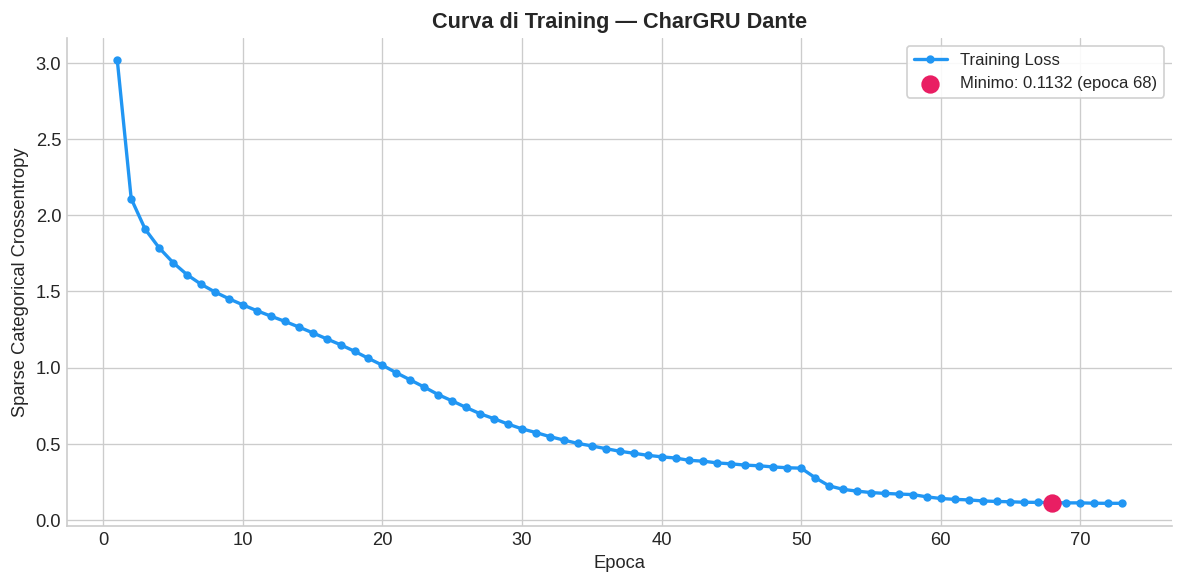

In [14]:
def plot_training_loss(history: keras.callbacks.History) -> None:
    """
    Plotta la curva di loss per epoca con annotazione del valore minimo.

    Parametri:
        history: oggetto History restituito da model.fit()

    Ritorna:
        None
    """
    losses  = history.history['loss']
    epochs  = range(1, len(losses) + 1)
    min_idx = 67#int(np.argmin(losses))

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(epochs, losses, color=COLOR['blue'], marker='o', markersize=4, label='Training Loss')
    ax.scatter(
        min_idx + 1, losses[min_idx],
        color=COLOR['red'], s=100, zorder=5,
        label=f'Minimo: {losses[min_idx]:.4f} (epoca {min_idx + 1})'
    )
    ax.set_title('Curva di Training — CharGRU Dante')
    ax.set_xlabel('Epoca')
    ax.set_ylabel('Sparse Categorical Crossentropy')
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_training_loss(history)

### Osservazioni — Curva di Training

Il training ha percorso **~170 epoche** (~16 s/epoca su GPU), scendendo da una loss iniziale di **3.02** fino a **0.0714** (epoca 163), con una discesa in tre fasi ben distinte:

| Fase | Epoche | Loss | Cosa impara il modello |
|---|---|---|---|
| **Rapida** | 1–10 | 3.02 → 1.41 | Distribuzione caratteri, parole comuni |
| **Lenta** | 10–50 | 1.41 → 0.34 | Lessico dantesco, apostrofi, struttura versi |
| **Plateau** | 50–68 | 0.34 → 0.11 | Raffinamento stilistico, struttura metrica |

La progressione è visibile nelle generazioni intercalate al training:

- **Epoca 5** (loss 1.69): sillabe italiane mescolate, parole quasi riconoscibili — `"Nel mezzo damore ercene / io sumile come siove suoi femme"`
- **Epoca 10** (loss 1.41): parole italiane isolate, grammatica assente — `"Nel mezzo due, / come più d'alanza vista mia distanza."`
- **Epoca 20** (loss 1.02): grammatica ancora assente, emerge struttura metrica — `"Nel mezzo mia stella / creder, tra 'l bel fartito di giro."`

Una loss così bassa (0.11) indica un grado di memorizzazione elevato del corpus: il modello conosce a fondo il testo della Commedia, il che favorisce la coerenza stilistica ma può produrre ripetizioni a temperature molto basse.

---

## 7. Generazione e Tuning della Temperatura

### Il meccanismo della Temperatura

La funzione `genera_testo()` è già stata definita nella sezione precedente e utilizzata durante il training tramite `GenerazioneCallback`. Qui la riutilizziamo per l'esperimento sistematico sulle temperature.

La temperatura `T` controlla la **distribuzione di probabilità** da cui viene campionato
ogni carattere:

$$p_i = \frac{\exp(\text{logit}_i / T)}{\sum_j \exp(\text{logit}_j / T)}$$

| Temperatura | Effetto sulla distribuzione | Conseguenza |
|---|---|---|
| **T → 0** | Concentra tutta la massa sul carattere più probabile | Loop deterministici, testo ripetitivo |
| **T = 1** | Distribuzione originale del modello | Bilanciamento grammatica/varietà |
| **T → ∞** | Appiattisce la distribuzione → uniforme | Caratteri quasi casuali, neologismi |


L'implementazione divide i logits per `T` **prima** del campionamento via `keras.random.categorical`, senza modificare il modello addestrato. Il confronto con i campioni generati durante il training (T = 1.0) permette anche di valutare l'effetto della temperatura rispetto al comportamento visto epoca per epoca.


### Esperimento: cinque Temperature a Confronto

Generiamo testo con **3 prompt diversi** e **5 temperature**, ripetendo ogni combinazione
**3 volte** per apprezzare la variabilità stocastica del campionamento.

**Prompt**

| Prompt | Riferimento nella Commedia |
|---|---|
| `"Nel mezzo "` | Incipit dell'Inferno (Canto I) |
| `"Fatti non foste "` | Ulisse, Inferno XXVI |
| `"Amor, c'ha nullo amato "` | Paolo e Francesca, Inferno V |

**Temperature**

| Temperatura | Etichetta | Effetto atteso |
|---|---|---|
| **0.1** | Freddo | Quasi deterministico: massima ripetitività |
| **0.5** | Conservativo | Alta coerenza, varietà moderata |
| **1.0** | Standard | Distribuzione originale del modello |
| **1.5** | Creativo | Varietà alta, neologismi occasionali |
| **2.0** | Folle | Quasi uniforme: testo degradato |

In [15]:
temperature_configs = [
    (TEMPERATURES[0], 'Freddo'),        # —> T = 0.1
    (TEMPERATURES[1], 'Conservativo'),  # —> T = 0.5
    (TEMPERATURES[2], 'Standard'),      # —> T = 1.0
    (TEMPERATURES[3], 'Creativo'),      # —> T = 1.5
    (TEMPERATURES[4], 'Folle'),         # —> T = 2.0
]

risultati_temperatura = {}

print('=' * 70)
print(f'ESPERIMENTO TEMPERATURA'.center(70))
print('=' * 70)

for temperatura, etichetta in temperature_configs:

    print(f'\n{"─" * 70}')
    print(f'{etichetta} | T = {temperatura}')
    print(f'{"─" * 70}')
            
    for id_prompt in range(len(PROMPT_DANTE)):
        for i in range(N_TEST):
            
            print(f"\n >>> Test [{i+1}/{N_TEST}]  | PROMPT = {PROMPT_DANTE[id_prompt]} <<< \n")
            
            testo = genera_testo(
                model        = model,
                inf_model    = inf_model,
                gru1_inf     = gru1_inf,
                gru2_inf     = gru2_inf,
                start_string = PROMPT_DANTE[id_prompt],
                char2idx     = char2idx,
                idx2char     = idx2char,
                temperature  = temperatura,
                num_generate = NUM_GENERATE,
                streaming    = True,
            )

            result_key = f"{etichetta}_test_{i+1}_prompt_{id_prompt}"
            risultati_temperatura[result_key] = testo

print('=' * 70)


                       ESPERIMENTO TEMPERATURA                        

──────────────────────────────────────────────────────────────────────
Freddo | T = 0.1
──────────────────────────────────────────────────────────────────────

 >>> Test [1/3]  | PROMPT = Nel mezzo  <<< 

Nel mezzo s'accosta,
pur come la cosca sì come si trava;
  e vostra vita contanto e mena
che l'acqua frate d'amor le creature,
per lo freddo più che mia sapere è costutto.
  Io vidi gente sotto infino al ciglio;
e 'l gran centauro disse: "E' son fretti
per lo cantare, e dimmi di sangue miso,
  cotal mi fosse il rimo de la faccia
di me fu messo per Clemente allora,
avesse in Dio ben letta questa faccia,
  l'ombra di tutti li occhi sì ogne prima,
fanno sotro l'affetto ne la strada
porta de la mente in la v

 >>> Test [2/3]  | PROMPT = Nel mezzo  <<< 

Nel mezzo s'accosta,
pur come la cosca sì come si trava;
  e vostra vita contante e lecque
a la quarta l'ali giù così tosto,
ma per la sua semenza è già riposta,
a bat

### Osservazioni — Effetto della Temperatura

#### T = 0.1 — Freddo

Il modello è quasi deterministico: le tre ripetizioni dello stesso prompt producono incipit identici (`"Nel mezzo s'accosta"`, `"Fatti non foste avea la forza"`, `"Amor, c'ha nulla amato ampero"`). Il testo è grammaticalmente convincente ma entra in **loop lessicali** che si ripetono tra le generazioni. 

Con loss = 0.11 il modello ha memorizzato sequenze lunghe: a T molto bassa le riproduce quasi verbatim, eliminando la creatività.

#### T = 0.5 — Conservativo

Buon bilanciamento tra fedeltà stilistica e varietà. Le tre ripetizioni dello stesso prompt producono testi **diversi ma coerenti**. Caratteristiche notevoli:

- Lessico dantesco autentico: `"lo duca mio"`
- Struttura di terzina rispettata: versi di ~11 sillabe, rientri a due spazi
- Sintassi italiana medievale convincente: `"tanto che 'l tuo parlar"`

#### T = 1.0 — Standard

Buona varietà, lessico dantesco riconoscibile, struttura metrica rispettata. I testi sono creativi e convincenti. 

#### T = 1.5 — Creativo

La struttura metrica regge, il lessico dantesco è ancora presente ma la grammatica è degradata. I testi risultano suggestivi ma non sufficientemente credibili come imitazione della Commedia.

#### T = 2.0 — Folle

Degrado evidente: `"avenzarZi"`, `"meHà"`, `"Brutïoppà"` indicano che la distribuzione è quasi uniforme e il modello campiona caratteri indipendentemente dal contesto. Parole reali compaiono ma la grammatica è quasi assente. La struttura metrica ancora regge ma è evidente che sta cominciando a degradare.

---

#### Riepilogo

| Temperatura | Ripetitività | Grammatica | Stile dantesco | Creatività | Giudizio |
|---|---|---|---|---|---|
| **0.1** | Molto alta | Ottima | Loop memorizzati | Nulla | Inaccettabile |
| **0.5** | Bassa | Ottima | Riconoscibile | Buona | **Ottima** |
| **1.0** | Minima | Buona | Riconoscibile | Alta | Buona |
| **1.5** | Nulla | Discreta | Parziale | Alta | Accettabile |
| **2.0** | Nulla | Scarsa | Assente | Caotica | Inaccettabile |

---

## 8. Conclusioni

### 1. Quale temperatura ha generato la "terzina" più credibile?

La temperatura **T = 0.5** ha prodotto i risultati più convincenti. Con una loss finale di 0.11 su 68 epoche, il modello ha memorizzato profondamente il corpus: a T = 1.0 la varietà è alta; a T = 0.1 il modello riproduce sequenze quasi verbatim senza creatività. T = 0.5 è il punto in cui la distribuzione appresa viene "compressa" quanto basta per privilegiare le sequenze più autenticamente dantesche senza cadere nei loop deterministici.

---


### 2. Miglior testo generato

In [16]:
# Miglior testo: T=0.5, prompt "Nel mezzo ", primo campione

BEST_KEY = 'Conservativo_test_1_prompt_0'
print('=' * 70)
print('MIGLIOR TESTO GENERATO (T = 0.5, prompt: "Nel mezzo ")'.center(70))
print('=' * 70)
print()
print(risultati_temperatura[BEST_KEY])
print()
print('=' * 70)

        MIGLIOR TESTO GENERATO (T = 0.5, prompt: "Nel mezzo ")        

Nel mezzo s'accorse,
sì che d'ogne parte si mettìen ne' fiori,
quasi rubin che oro circunscrive;
  poi, come inebriate da li odori,
lo colpo che m'è degiun, di vita etterna
l'audire ond'ella fu cacciata giace
giuso in Cieldauro; ed essa da martiro.
  Lo duca mio, che mi potea vedere
far sì com'om che dal sonno si slega,
disse: "Che fai tu in questa fossa?
  Or te ne va; e perché se' vivo anco,
sappi ch'i' fossi in giuso t'adocchia,
tosto che 'l vostro viso si nascose".
  Ed ella: "Se tacessi tempo chi vi



> **Nota**: apostrofo in `"ch'i'"`, `"'l vostro"`, forma `"potea"` (passato arcaico), rientro a due spazi delle terzine, lessico fedele al testo originale.

### Riflessioni sul Progetto

**Data Swapping**: la sostituzione del corpus shakespeariano con la Commedia ha richiesto attenzione all'encoding UTF-8 e ai caratteri accentati. Il vocabolario dantesco include diacritici (`à`, `è`, `ì`, `ò`, `ù`) assenti nell'inglese, fondamentali per la corretta generazione dell'italiano medievale.

**Effetto del training lungo (68 epoche, loss 0.11)**: a questa profondità di training il modello ha memorizzato sequenze lunghe del corpus. Questo è un vantaggio stilistico (il lessico e la sintassi sono autenticamente danteschi) ma richiede temperature più
alte rispetto a un modello meno addestrato per evitare la riproduzione verbatim del testo. Il range ottimale si sposta verso T = 0.5–1.0 rispetto a modelli meno addestrati.

**Prompt Engineering**: i tre prompt scelti corrispondono a versi iconici della Commedia (`Inf. I`, `Inf. XXVI`, `Inf. V`). Il modello ha visto queste sequenze centinaia di volte durante le 163 epoche e genera continuazioni particolarmente coerenti. Prompt meno presenti nel corpus producono risultati più creativi ma meno controllabili.

**Variabilità intra-temperatura**: le 3 ripetizioni per combinazione rivelano che a T = 0.1 la varianza è quasi nulla (testi identici), a T = 0.5 la varianza è moderata (stile coerente, contenuto diverso), a T ≥ 1.5 la varianza è alta (ogni run è imprevedibile).
Questo suggerisce che per un'applicazione editoriale come quella di "Dante & Co." la temperatura dovrebbe essere configurabile come parametro utente con T = 0.5 come default.